# 05 - model training (preliminary experiments)

train mfcc + svm baseline on sample data. get real numbers for midterm report.

In [ ]:
import time, joblib
import pandas as pd
import numpy as np
import librosa
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append('../../')
from src.config.settings import SAMPLES, FIGURES_DIR
from src.utils.feature_engineering import extract_mfcc

In [2]:
df = pd.read_csv(SAMPLES / "sample_labels.csv")
df.head()

,filepath,channel,emotion_code,emotion,intensity,statement,repetition,actor,gender,split
0,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,1,1,23,male,test
1,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,1,2,23,male,test
2,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,2,1,23,male,test
3,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,2,2,23,male,test
4,/mnt/d/career/projects/lightweight-speech-emot...,song,2,calm,normal,1,1,23,male,test


In [3]:
emotion_map = {1:'neutral',2:'calm',3:'happy',4:'sad',5:'angry',6:'fearful',7:'disgust',8:'surprised'}
print(f"{len(df)} files loaded")

416 files loaded


## 1. extract mfcc features

In [4]:
train = df[df['split']=='train']
test = df[df['split']=='test']
print(f"train: {len(train)}, test: {len(test)}")

train: 208, test: 104


In [5]:
t0 = time.time()
X_train = np.array([extract_mfcc(fp) for fp in train['filepath']])
X_test = np.array([extract_mfcc(fp) for fp in test['filepath']])
y_train, y_test = train['emotion_code'].values, test['emotion_code'].values
t1 = time.time()
print(f"extraction: {t1-t0:.1f}s for {len(train)+len(test)} clips")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

extraction: 18.9s for 312 clips
X_train: (208, 240), X_test: (104, 240)


## 2. train svm

In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [7]:
t0 = time.time()
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_s, y_train)
t1 = time.time()
print(f"training: {t1-t0:.2f}s")

training: 0.04s


In [8]:
y_pred = svm.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)
print(f"\ntest accuracy: {acc*100:.1f}%\n")
print(classification_report(y_test, y_pred, target_names=list(emotion_map.values()), digits=3))


test accuracy: 27.9%

              precision    recall  f1-score   support

     neutral      1.000     0.125     0.222         8
        calm      0.368     0.438     0.400        16
       happy      0.500     0.438     0.467        16
         sad      0.000     0.000     0.000        16
       angry      0.368     0.438     0.400        16
     fearful      0.231     0.188     0.207        16
     disgust      0.000     0.000     0.000         8
   surprised      0.129     0.500     0.205         8

    accuracy                          0.279       104
   macro avg      0.325     0.266     0.238       104
weighted avg      0.313     0.279     0.260       104



/home/aang/miniconda3/envs/speechrecog/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aang/miniconda3/envs/speechrecog/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aang/miniconda3/envs/speechrecog/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

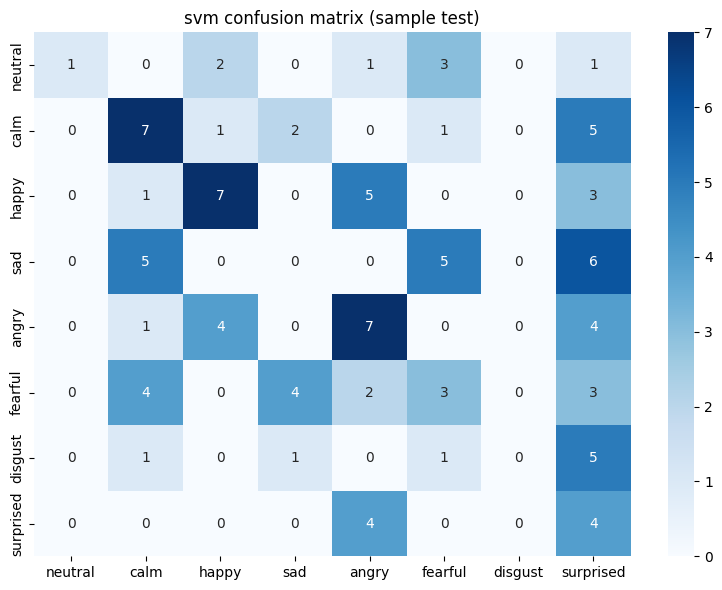

correct: 29/104 (27.9%)


In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_map.values()),
            yticklabels=list(emotion_map.values()))
plt.title('svm confusion matrix (sample test)')
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'fig01-svm-confusion-matrix.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"correct: {np.trace(cm)}/{len(y_test)} ({np.trace(cm)/len(y_test)*100:.1f}%)")

## 3. timing + model export

In [10]:
n_runs = 50
single = X_test_s[0:1]
t0 = time.time()
for _ in range(n_runs):
    svm.predict(single)
t1 = time.time()
single_ms = (t1-t0)/n_runs*1000

batch = X_test_s[:32]
t0 = time.time()
for _ in range(n_runs):
    svm.predict(batch)
t1 = time.time()
batch_ms = (t1-t0)/n_runs*1000
print(f"inference: {single_ms:.2f}ms (single), {batch_ms:.2f}ms (batch 32)")

inference: 0.51ms (single), 3.80ms (batch 32)


In [11]:
model_path = SAMPLES / 'svm_baseline_sample.pkl'
joblib.dump(svm, model_path)
size_kb = model_path.stat().st_size / 1024
print(f"model: {size_kb:.1f} kb")

model: 411.9 kb


## results (for midterm report)

fill into 05-preliminary-experiments-and-results.md:
- test accuracy: x.x%
- total clips: x
- extraction time: x.xs for x clips
- training time: x.xs
- single inference: x.xxms
- model size: x.x kb